In [1]:
#importing necessary functions
#%matplotlib inline
from netCDF4 import Dataset
import numpy as np
from netCDF4 import num2date, date2num
import datetime
from datetime import datetime, timedelta
import matplotlib.pyplot as plt
import metpy.calc as mcalc
import metpy
from metpy.units import units
from metpy.calc import dewpoint_from_relative_humidity as dewpoint_rh
from metpy.calc import specific_humidity_from_dewpoint, wind_components, altimeter_to_sea_level_pressure, altimeter_to_station_pressure
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import tables
import math
from pydl import uniq
from cartopy.io.shapereader import Reader
from cartopy.feature import ShapelyFeature
from metpy.interpolate import interpolate_to_grid
import pyart


## You are using the Python ARM Radar Toolkit (Py-ART), an open source
## library for working with weather radar data. Py-ART is partly
## supported by the U.S. Department of Energy as part of the Atmospheric
## Radiation Measurement (ARM) Climate Research Facility, an Office of
## Science user facility.
##
## If you use this software to prepare a publication, please cite:
##
##     JJ Helmus and SM Collis, JORS 2016, doi: 10.5334/jors.119



<frozen importlib._bootstrap>:283: DeprecationWarning: the load_module() method is deprecated and slated for removal in Python 3.12; use exec_module() instead


In [2]:
#Put analysis time here
time_bracket = datetime(2019,6,9,0,15,0)

In [3]:
#You'll need to replace the files here with those from your case
#CoMET 1:
CoMET1 = Dataset('UNL.CoMeT1.20190608.1606.L2.g1.a2.ts2.rh1.cdf', 'r', format='NETCDF4')
CoMET2 = Dataset('UNL.CoMeT2.20190608.1618.L2.g1.cdf', 'r', format='NETCDF4')
CoMET3 = Dataset('UNL.CoMeT3.20190608.1623.L2.a1.g1.f1.cdf', 'r', format='NETCDF4')

#print(CoMET1.variables)
C1_T = (np.asarray(CoMET1.variables['fast_temp'][:])*units('degK'))
C1_P = (np.asarray((CoMET1.variables['pressure'][:])/100)*units('hPa'))
C1_Td = (np.asarray(CoMET1.variables['dewpoint'][:])*units('degK'))
C1_Spd = (np.asarray(CoMET1.variables['wind_speed'][:])*units('m/s'))
C1_Dir = (np.asarray(CoMET1.variables['wind_dir'][:])*units('degree'))
C1_lat = CoMET1.variables['lat'][:]
C1_lon = CoMET1.variables['lon'][:]
C1_alt = CoMET1.variables['alt'][:]

C1_u, C1_v = wind_components(C1_Spd, C1_Dir)

C2_T = (np.asarray(CoMET2.variables['fast_temp'][:])*units('degK'))
C2_P = (np.asarray((CoMET2.variables['pressure'][:])/100)*units('hPa'))
C2_Td = (np.asarray(CoMET2.variables['dewpoint'][:])*units('degK'))
C2_Spd = (np.asarray(CoMET2.variables['wind_speed'][:])*units('m/s'))
C2_Dir = (np.asarray(CoMET2.variables['wind_dir'][:])*units('degree'))
C2_lat = CoMET2.variables['lat'][:]
C2_lon = CoMET2.variables['lon'][:]
C2_alt = CoMET2.variables['alt'][:]

C2_u, C2_v = wind_components(C2_Spd, C2_Dir)

C3_T = (np.asarray(CoMET3.variables['fast_temp'][:])*units('degK'))
C3_P = (np.asarray((CoMET3.variables['pressure'][:])/100)*units('hPa'))
C3_Td = (np.asarray(CoMET3.variables['dewpoint'][:])*units('degK'))
C3_Spd = (np.asarray(CoMET3.variables['wind_speed'][:])*units('m/s'))
C3_Dir = (np.asarray(CoMET3.variables['wind_dir'][:])*units('degree'))
C3_lat = CoMET3.variables['lat'][:]
C3_lon = CoMET3.variables['lon'][:]
C3_alt = CoMET3.variables['alt'][:]

C3_u, C3_v = wind_components(C3_Spd, C3_Dir)

#Get the times from CoMET1
C1_time = CoMET1.variables['time'][:]
C2_time = CoMET2.variables['time'][:]
C3_time = CoMET3.variables['time'][:]

print(C1_time)

C1_utc = []
for i in range(len(C1_time)):
    utc_time = datetime(1970,1,1) + timedelta(seconds=C1_time[i])
    #print(utc_time)
    C1_utc.append(utc_time)
    
C2_utc = []
for i in range(len(C2_time)):
    utc_time = datetime(1970,1,1) + timedelta(seconds=C2_time[i])
    #print(utc_time)
    C2_utc.append(utc_time)
    
C3_utc = []
for i in range(len(C3_time)):
    utc_time = datetime(1970,1,1) + timedelta(seconds=C3_time[i])
    #print(utc_time)
    C3_utc.append(utc_time)

C:\Users\matts\anaconda3\envs\map2\lib\site-packages\metpy\calc\basic.py:1274: UserWarning: Input over 12.566370614359172 radians. Ensure proper units are given.
  warnings.warn('Input over {} radians. '


[  1.56000996e+09   1.56000997e+09   1.56000997e+09 ...,   1.56005825e+09
   1.56005825e+09   1.56005825e+09]


In [4]:
#Start date--change this for each case
#The OU files are weird in that time is in seconds since 00 UTC that day
#Also you might have different numbers of OU files for different cases.
MMstart = datetime(2019, 6, 8, 0, 0)

MM3 = np.genfromtxt('Prb1_190608_QC_met.dat.csv', delimiter = ',', usecols=(1,2,3,4,5,6,7,8,9,10))

MM3_T = (MM3[:,4]*units('degC')).to('degK')
MM3_RH = MM3[:,6]
MM3_P = (MM3[:,7]*units('hPa'))
MM3_Spd = (MM3[:,9]*units('m/s'))
MM3_Dir = MM3[:,8]*units('degree')
MM3_lat = MM3[:,1]
MM3_lon = MM3[:,2]
MM3_alt = MM3[:,3]

#Get dewpoint from T, RH, and P

MM3_Td = dewpoint_rh(MM3_T, MM3_RH/100).to('degK')
#Convert times into correct format
MM3_dt = []
for i in range(len(MM3[:,0])):
    MM3_di = MMstart + timedelta(hours = MM3[i,0])
    #print(MM3_di)
    MM3_d = (MM3_di-datetime(1970,1,1,0,0)).total_seconds()
    MM3_dt.append(MM3_d)
    
MM3_dt = np.asarray(MM3_dt)

MM3_u, MM3_v = wind_components(MM3_Spd, MM3_Dir)

MM4 = np.genfromtxt('Prb2_190608_QC_met.dat.csv', delimiter = ',', usecols=(1,2,3,4,5,6,7,8,9,10))

MM4_T = (MM4[:,4]*units('degC')).to('degK')
MM4_RH = MM4[:,6]
MM4_P = (MM4[:,7]*units('hPa'))
MM4_Spd = (MM4[:,9]*units('m/s'))
MM4_Dir = MM4[:,8]*units('degree')
MM4_lat = MM4[:,1]
MM4_lon = MM4[:,2]
MM4_alt = MM4[:,3]

#Get dewpoint from T, RH, and P

MM4_Td = dewpoint_rh(MM4_T, MM4_RH/100).to('degK')
#Convert times into correct format
MM4_dt = []
for i in range(len(MM4[:,0])):
    MM4_di = MMstart + timedelta(hours = MM4[i,0])
    #print(MM4_di)
    MM4_d = (MM4_di-datetime(1970,1,1,0,0)).total_seconds()
    MM4_dt.append(MM4_d)
    
MM4_dt = np.asarray(MM4_dt)

MM4_u, MM4_v = wind_components(MM4_Spd, MM4_Dir)

#MM2: Lidar
MM2 = np.genfromtxt('LIDR_190608_QC_met.dat.csv', delimiter = ',', usecols=(1,2,3,4,5,6,7,8,9,10))

MM2_T = (MM2[:,4]*units('degC')).to('degK')
MM2_RH = MM2[:,6]
MM2_P = (MM2[:,7]*units('hPa'))
MM2_Spd = (MM2[:,9]*units('m/s'))
MM2_Dir = MM2[:,8]*units('degree')
MM2_lat = MM2[:,1]
MM2_lon = MM2[:,2]
MM2_alt = MM2[:,3]

#Get dewpoint from T, RH, and P

MM2_Td = dewpoint_rh(MM2_T, MM2_RH/100).to('degK')
#Convert times into correct format
#MM2 is apparently missing data between 2323z and 00z
MM2_dt = []
for i in range(len(MM2[:,0])):
    MM2_di = MMstart + timedelta(hours = MM2[i,0])
    #print(MM2_di)
    MM2_d = (MM2_di-datetime(1970,1,1,0,0)).total_seconds()
    MM2_dt.append(MM2_d)
    
MM2_dt = np.asarray(MM2_dt)

MM2_u, MM2_v = wind_components(MM2_Spd, MM2_Dir)


In [5]:
#time_bracket = datetime(2019,6,8,18,0,0)

dt_init = (time_bracket-datetime(1970,1,1)).total_seconds()
dt_time3  = time_bracket - datetime(1601,1,1,0,0,0)
dt3 = dt_init - 450
dt4 = dt_init + 450

print(dt_init, dt3)

1560039300.0 1560038850.0


In [6]:
#Subset out the data for each interval

# dt3 = (datetime(2019,6,8,21,37,30)-datetime(1970,1,1)).total_seconds()
# dt4 = (datetime(2019,6,8,21,52,30)-datetime(1970,1,1)).total_seconds()


inds_int3 = np.where(np.logical_and(C1_time < dt4,  C1_time > dt3))
int3_p = C1_P[inds_int3]
int3_T = C1_T[inds_int3]
int3_Td = C1_Td[inds_int3]
int3_U = C1_u[inds_int3]
int3_V = C1_v[inds_int3]
int3_lon = C1_lon[inds_int3]
int3_lat = C1_lat[inds_int3]
int3_alt = C1_alt[inds_int3]

#CoMET2 data for the same time

inds2_int3 = np.where(np.logical_and(C2_time < dt4,  C2_time > dt3))
int3_p2 = C2_P[inds2_int3]
int3_T2 = C2_T[inds2_int3]
int3_Td2 = C2_Td[inds2_int3]
int3_U2 = C2_u[inds2_int3]
int3_V2 = C2_v[inds2_int3]
int3_lon2 = C2_lon[inds2_int3]
int3_lat2 = C2_lat[inds2_int3]
int3_alt2 = C2_alt[inds2_int3]

#CoMET3 data for the same time

inds3_int3 = np.where(np.logical_and(C3_time < dt4,  C3_time > dt3))
int3_p3 = C3_P[inds3_int3]
int3_T3 = C3_T[inds3_int3]
int3_Td3 = C3_Td[inds3_int3]
int3_U3 = C3_u[inds3_int3]
int3_V3 = C3_v[inds3_int3]
int3_lon3 = C3_lon[inds3_int3]
int3_lat3 = C3_lat[inds3_int3]
int3_alt3 = C3_alt[inds3_int3]

#Probe1 data for the same time

inds4_int3 = np.where(np.logical_and(MM3_dt < dt4,  MM3_dt > dt3))
int3_p4 = MM3_P[inds4_int3]
int3_T4 = MM3_T[inds4_int3]
int3_Td4 = MM3_Td[inds4_int3]
int3_U4 = MM3_u[inds4_int3]
int3_V4 = MM3_v[inds4_int3]
int3_lon4 = MM3_lon[inds4_int3]
int3_lat4 = MM3_lat[inds4_int3]
int3_alt4 = MM3_alt[inds4_int3]

#Probe2 data for the same time

inds5_int3 = np.where(np.logical_and(MM4_dt < dt4,  MM4_dt > dt3))
int3_p5 = MM4_P[inds5_int3]
int3_T5 = MM4_T[inds5_int3]
int3_Td5 = MM4_Td[inds5_int3]
int3_U5 = MM4_u[inds5_int3]
int3_V5 = MM4_v[inds5_int3]
int3_lon5 = MM4_lon[inds5_int3]
int3_lat5 = MM4_lat[inds5_int3]
int3_alt5 = MM4_alt[inds5_int3]

#LIDR data for the same time

inds6_int3 = np.where(np.logical_and(MM2_dt < dt4,  MM2_dt > dt3))
int3_p6 = MM2_P[inds6_int3]
int3_T6 = MM2_T[inds6_int3]
int3_Td6 = MM2_Td[inds6_int3]
int3_U6 = MM2_u[inds6_int3]
int3_V6 = MM2_v[inds6_int3]
int3_lon6 = MM2_lon[inds6_int3]
int3_lat6 = MM2_lat[inds6_int3]
int3_alt6 = MM2_alt[inds6_int3]

In [7]:
#Concatenate them all into one big array
P_all = np.concatenate([int3_p, int3_p2, int3_p3, int3_p4, int3_p5, int3_p6])
T_all = np.concatenate([int3_T, int3_T2, int3_T3, int3_T4, int3_T5, int3_T6])
Td_all = np.concatenate([int3_Td, int3_Td2, int3_Td3, int3_Td4, int3_Td5, int3_Td6])
U_all = np.concatenate([int3_U, int3_U2, int3_U3, int3_U4, int3_U5, int3_U6])
V_all = np.concatenate([int3_V, int3_V2, int3_V3, int3_V4, int3_V5, int3_V6])
lon_all = np.concatenate([int3_lon, int3_lon2, int3_lon3, int3_lon4, int3_lon5, int3_lon6])
lat_all = np.concatenate([int3_lat, int3_lat2, int3_lat3, int3_lat4, int3_lat5, int3_lat6])
alt_all = np.concatenate([int3_alt, int3_alt2, int3_alt3, int3_alt4, int3_alt5, int3_alt6])

In [8]:
def superob_grid(mean_lon2, mean_lat2, mean_P2, mean_T2, mean_Td2, mean_U2, mean_V2, mean_alt2):
    #Convert the input lats and lons to an equal area projection
    Albers_m = ccrs.AlbersEqualArea(central_longitude=-99.0, central_latitude=35.0, false_easting=0.0,
                                    false_northing=0.0, standard_parallels=(20.0, 50.0), globe=None)
    #IMPORTANT!!! You probably will need to change this lat/lon box for different cases.
    init_lons = np.asarray([-103.0, -100.0])
    init_lats = np.asarray([38.0, 40.0])
    dummy_latloni = Albers_m.transform_points(ccrs.PlateCarree(), init_lons, init_lats)
    lon_dummyi = dummy_latloni[:,0]
    lat_dummyi = dummy_latloni[:,1]
    
    dummy_latlon3 = Albers_m.transform_points(ccrs.PlateCarree(), mean_lon2, mean_lat2)

    lon_dummy3 = dummy_latlon3[:,0]
    lat_dummy3 = dummy_latlon3[:,1]


    grid_x, grid_y, grid_T = interpolate_to_grid(np.ndarray.flatten(lon_dummy3), np.ndarray.flatten(lat_dummy3), np.ndarray.flatten(mean_T2), 
                                                 hres=6000, interp_type='cressman', search_radius = 6000, minimum_neighbors=3,
                                                 boundary_coords={'west':lon_dummyi[0], 'south':lat_dummyi[0], 'east':lon_dummyi[1], 'north':lat_dummyi[1]})

    _, _, grid_Td = interpolate_to_grid(np.ndarray.flatten(lon_dummy3), np.ndarray.flatten(lat_dummy3), np.ndarray.flatten(mean_Td2), 
                                                 hres=6000, interp_type='cressman', search_radius = 6000, minimum_neighbors=3,
                                                 boundary_coords={'west':lon_dummyi[0], 'south':lat_dummyi[0], 'east':lon_dummyi[1], 'north':lat_dummyi[1]})
#             print('temps')
    _, _, grid_U = interpolate_to_grid(np.ndarray.flatten(lon_dummy3), np.ndarray.flatten(lat_dummy3), np.ndarray.flatten(mean_U2), 
                                                 hres=6000, interp_type='cressman', search_radius = 6000, minimum_neighbors=3,
                                                 boundary_coords={'west':lon_dummyi[0], 'south':lat_dummyi[0], 'east':lon_dummyi[1], 'north':lat_dummyi[1]})
#             print('temps')
    _, _, grid_V = interpolate_to_grid(np.ndarray.flatten(lon_dummy3), np.ndarray.flatten(lat_dummy3), np.ndarray.flatten(mean_V2), 
                                                 hres=6000, interp_type='cressman', search_radius = 6000, minimum_neighbors=3,
                                                 boundary_coords={'west':lon_dummyi[0], 'south':lat_dummyi[0], 'east':lon_dummyi[1], 'north':lat_dummyi[1]})

    _, _, grid_P = interpolate_to_grid(np.ndarray.flatten(lon_dummy3), np.ndarray.flatten(lat_dummy3), np.ndarray.flatten(mean_P2), 
                                                 hres=6000, interp_type='cressman', search_radius = 6000, minimum_neighbors=3,
                                                 boundary_coords={'west':lon_dummyi[0], 'south':lat_dummyi[0], 'east':lon_dummyi[1], 'north':lat_dummyi[1]})
   
    _, _, grid_alt = interpolate_to_grid(np.ndarray.flatten(lon_dummy3), np.ndarray.flatten(lat_dummy3), np.ndarray.flatten(mean_alt2), 
                                                 hres=6000, interp_type='cressman', search_radius = 6000, minimum_neighbors=3,
                                                 boundary_coords={'west':lon_dummyi[0], 'south':lat_dummyi[0], 'east':lon_dummyi[1], 'north':lat_dummyi[1]})


    grid_latlon = ccrs.PlateCarree().transform_points(Albers_m, grid_x, grid_y)
#             print(grid_latlon.shape)
    grid_x1 = grid_latlon[:,:,0]
    grid_y1 = grid_latlon[:,:,1]

#         print('to appending')
    T_levs = grid_T
    Td_levs = grid_Td
    U_levs = grid_U
    V_levs = grid_V
    P_levs = grid_P

    lon_levs = grid_x1 
    lat_levs = grid_y1
    
    alt_levs = grid_alt

    return T_levs, Td_levs, U_levs, V_levs, P_levs, lon_levs, lat_levs, alt_levs

In [9]:
#Now let's grid that data
T_levs3, Td_levs3, U_levs3, V_levs3, P_levs3, lon_levs3, lat_levs3, alt_levs3 = superob_grid(lon_all,
                                                                                  lat_all,
                                                                                  P_all.magnitude,
                                                                                  T_all.magnitude,
                                                                                  Td_all.magnitude, 
                                                                                  U_all.magnitude, 
                                                                                  V_all.magnitude,
                                                                                  alt_all)

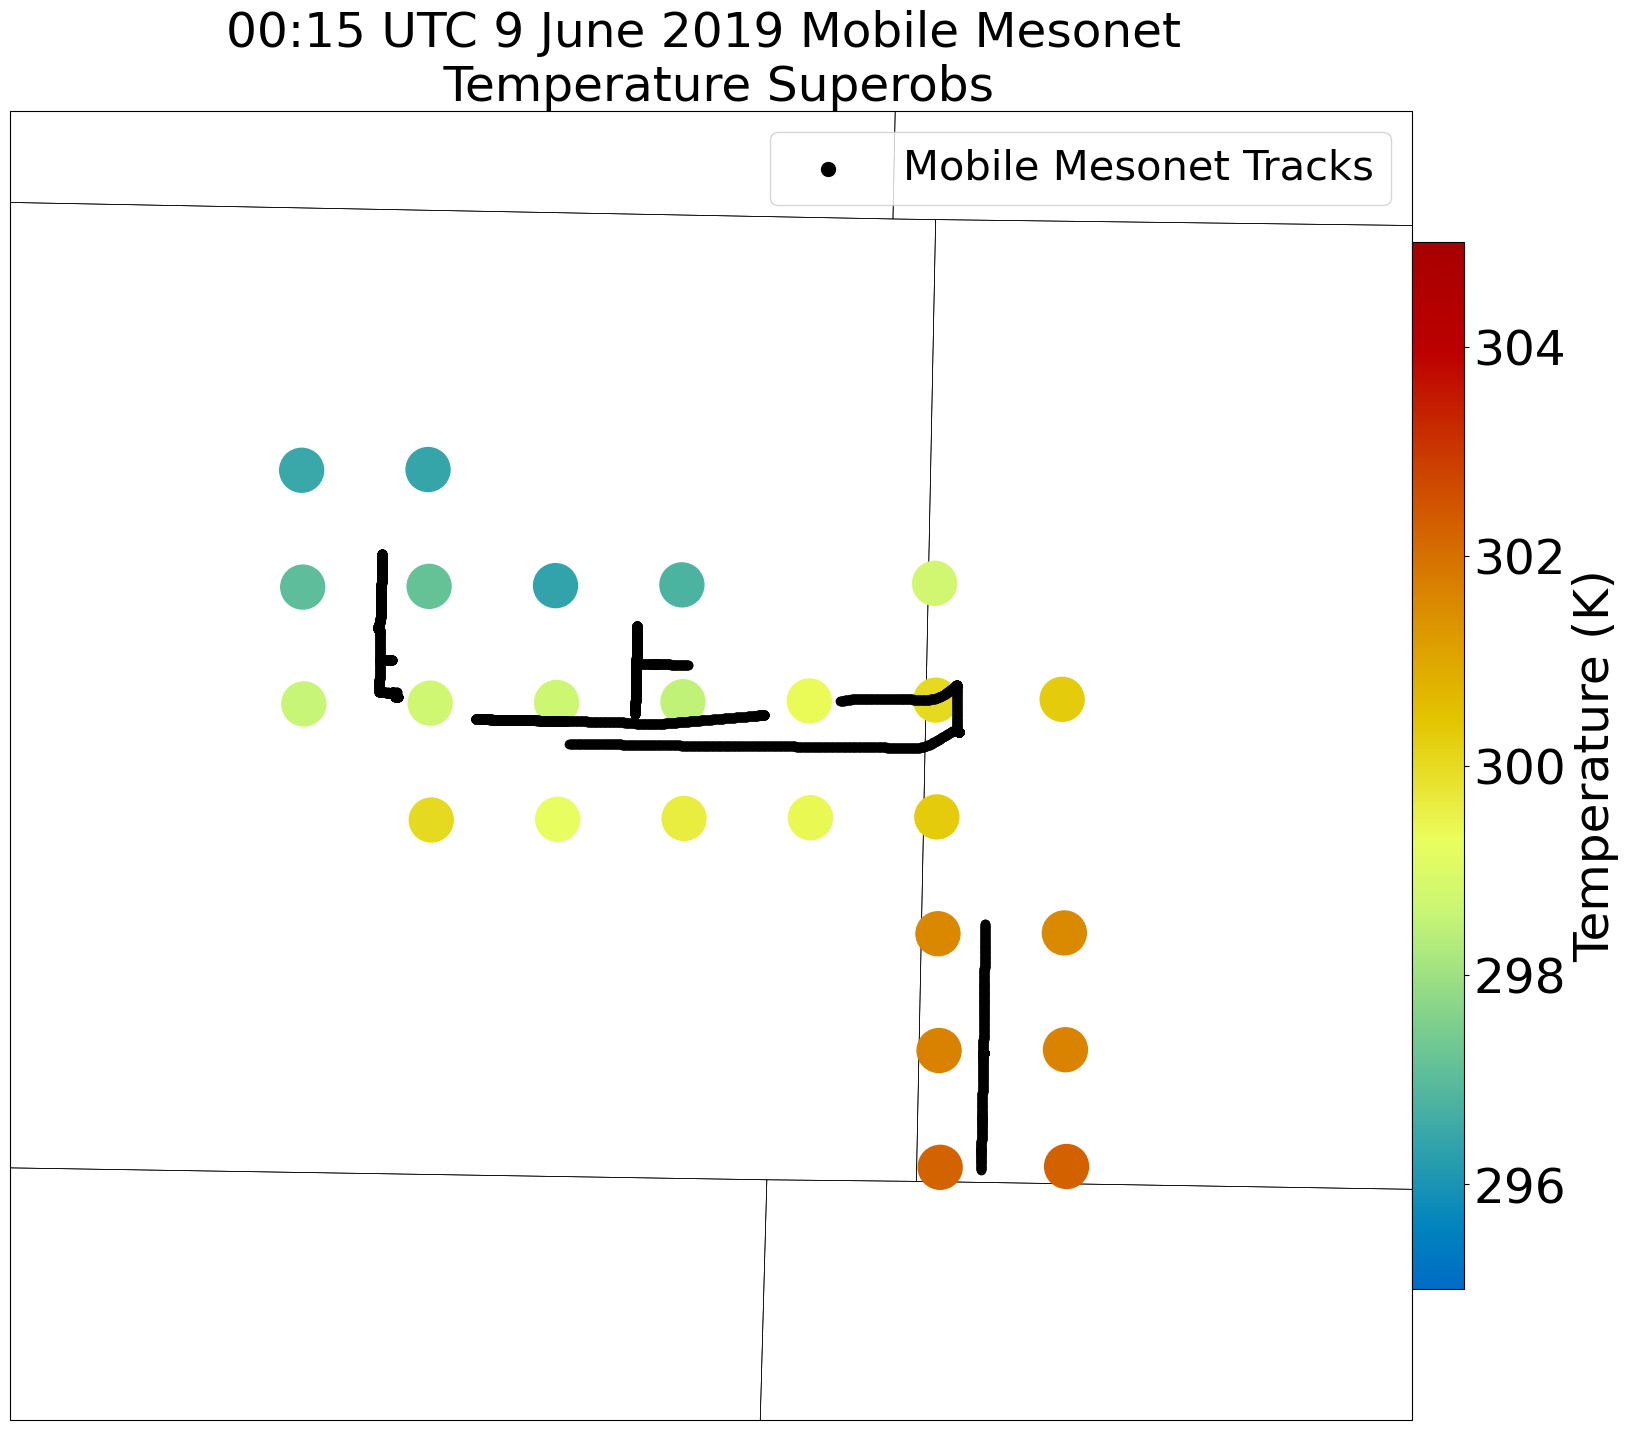

In [12]:
#Now let's plot a map with all of the supercell cases on it

lat = np.mean(lat_levs3[~np.isnan(T_levs3)])
lon = np.mean(lon_levs3[~np.isnan(T_levs3)])
# lat = 39.3
# lon = -101.7
cenlat1 = float(lat)
cenlon1 = float(lon)


#Let's set up the map projection!
# Set up our projection
crs = ccrs.LambertConformal(central_longitude=-100.0, central_latitude=45.0)
# Limit the extent of the map area, must convert to proper coords.
LL1 = crs.transform_point(cenlon1-0.4,cenlat1-0.3,ccrs.PlateCarree())
UR1 = crs.transform_point(cenlon1+0.4,cenlat1+0.3,ccrs.PlateCarree())

# LL1 = crs.transform_point(cenlon1-2.5,cenlat1-1.6,ccrs.PlateCarree())
# UR1 = crs.transform_point(cenlon1+1.5,cenlat1+1.6,ccrs.PlateCarree())

# Get data to plot state and province boundaries
states_provinces = cfeature.NaturalEarthFeature(
        category='cultural',
        name='admin_1_states_provinces_lakes',
        scale='50m',
        facecolor='none')

#Make sure these shapefiles are in the same directory as the script
fname = 'C:/Users/matts/Documents/Python Scripts/SPORK Analysis Scripts/cb_2016_us_county_20m/cb_2016_us_county_20m.shp'
fname2 = 'C:/Users/matts/Documents/Python Scripts/SPORK Analysis Scripts/cb_2016_us_state_20m/cb_2016_us_state_20m.shp'
counties = ShapelyFeature(Reader(fname).geometries(),ccrs.PlateCarree(), facecolor = 'none', edgecolor = 'black')
states = ShapelyFeature(Reader(fname2).geometries(),ccrs.PlateCarree(), facecolor = 'none', edgecolor = 'black')

%matplotlib inline
#plt.style.use('bmh')
# Choose Forecast Hour (FH), FH = 0 is the first hour of dataset
# You can change and rerun this cell to get the different forecast hour
FH = 0
fig=plt.figure(1,figsize=(26.,17.))
ax = plt.subplot(111,projection=crs)
#   ax.set_extent([west long, east long, south lat, north lat])
ax.set_extent([LL1[0],UR1[0],LL1[1],UR1[1]],crs)
ax.coastlines('50m',edgecolor='black',linewidth=0.75)
#ax.add_feature(states_provinces,edgecolor='black',linewidth=0.5)
ax.add_feature(counties, edgecolor = 'black', linewidth = 0.5)
ax.add_feature(states, edgecolor = 'black', linewidth = 1.5)

#plt.scatter(Tmean_lon4, Tmean_lat4, c=Tmean_T4, transform=ccrs.PlateCarree())

size=8000/8

sc1 = plt.scatter(lon_levs3[~np.isnan(T_levs3)], lat_levs3[~np.isnan(T_levs3)], c=T_levs3[~np.isnan(T_levs3)], cmap=pyart.graph.cm_colorblind.HomeyerRainbow, s=size, transform=ccrs.PlateCarree(), zorder=20, vmin=295, vmax=305)

mm1 = plt.scatter(int3_lon, int3_lat, c='k', transform=ccrs.PlateCarree(), vmin=0, vmax=4000, cmap=plt.cm.magma, zorder=20, label='Mobile Mesonet Tracks')
plt.scatter(int3_lon2, int3_lat2, c='k', transform=ccrs.PlateCarree(), vmin=0, vmax=4000, cmap=plt.cm.magma, zorder=20, label='CoMET 2')
plt.scatter(int3_lon3, int3_lat3, c='k', transform=ccrs.PlateCarree(), vmin=0, vmax=4000, cmap=plt.cm.magma, zorder=20, label='CoMET 3')
plt.scatter(int3_lon4, int3_lat4, c='k', transform=ccrs.PlateCarree(), vmin=0, vmax=4000, cmap=plt.cm.magma, zorder=20, label='Probe 1')
plt.scatter(int3_lon5, int3_lat5, c='k', transform=ccrs.PlateCarree(), vmin=0, vmax=4000, cmap=plt.cm.magma, zorder=20, label='Probe 2')
plt.scatter(int3_lon6, int3_lat6, c='k', transform=ccrs.PlateCarree(), vmin=0, vmax=4000, zorder=20, label='LIDAR')

lgnd=plt.legend(fontsize=30, handles = [mm1])
lgnd.legendHandles[0].set_sizes([100])

cg2 = plt.colorbar(sc1, shrink=0.80, pad=0.0)
cg2.ax.tick_params(labelsize=35)
cg2.set_label("Temperature (K)",size = 35)

plt.title('00:15 UTC 9 June 2019 Mobile Mesonet \n Temperature Superobs', size=35)

plt.savefig('MM_GRID_0015poster.png', bbox_inches='tight')

In [ ]:
#Now let's plot a map with all of the supercell cases on it
# lat = 39.3
# lon = -101.7

lat = np.mean(lat_levs3[~np.isnan(T_levs3)])
lon = np.mean(lon_levs3[~np.isnan(T_levs3)])

cenlat1 = float(lat)
cenlon1 = float(lon)


#Let's set up the map projection!
# Set up our projection
crs = ccrs.LambertConformal(central_longitude=-100.0, central_latitude=45.0)
# Limit the extent of the map area, must convert to proper coords.
LL1 = crs.transform_point(cenlon1-0.8,cenlat1-0.5,ccrs.PlateCarree())
UR1 = crs.transform_point(cenlon1+0.8,cenlat1+0.5,ccrs.PlateCarree())

# LL1 = crs.transform_point(cenlon1-2.5,cenlat1-1.6,ccrs.PlateCarree())
# UR1 = crs.transform_point(cenlon1+1.5,cenlat1+1.6,ccrs.PlateCarree())

# Get data to plot state and province boundaries
states_provinces = cfeature.NaturalEarthFeature(
        category='cultural',
        name='admin_1_states_provinces_lakes',
        scale='50m',
        facecolor='none')

#Make sure these shapefiles are in the same directory as the script
fname = 'C:/Users/matts/Documents/Python Scripts/SPORK Analysis Scripts/cb_2016_us_county_20m/cb_2016_us_county_20m.shp'
fname2 = 'C:/Users/matts/Documents/Python Scripts/SPORK Analysis Scripts/cb_2016_us_state_20m/cb_2016_us_state_20m.shp'
counties = ShapelyFeature(Reader(fname).geometries(),ccrs.PlateCarree(), facecolor = 'none', edgecolor = 'black')
states = ShapelyFeature(Reader(fname2).geometries(),ccrs.PlateCarree(), facecolor = 'none', edgecolor = 'black')

%matplotlib inline
#plt.style.use('bmh')
# Choose Forecast Hour (FH), FH = 0 is the first hour of dataset
# You can change and rerun this cell to get the different forecast hour
FH = 0
fig=plt.figure(1,figsize=(26.,17.))
ax = plt.subplot(111,projection=crs)
#   ax.set_extent([west long, east long, south lat, north lat])
ax.set_extent([LL1[0],UR1[0],LL1[1],UR1[1]],crs)
ax.coastlines('50m',edgecolor='black',linewidth=0.75)
#ax.add_feature(states_provinces,edgecolor='black',linewidth=0.5)
ax.add_feature(counties, edgecolor = 'black', linewidth = 0.5)
ax.add_feature(states, edgecolor = 'black', linewidth = 1.5)

#plt.scatter(Tmean_lon4, Tmean_lat4, c=Tmean_T4, transform=ccrs.PlateCarree())

size=8000/8

sc1 = plt.scatter(lon_levs3[~np.isnan(U_levs3)], lat_levs3[~np.isnan(U_levs3)], c=V_levs3[~np.isnan(U_levs3)], s=size, transform=ccrs.PlateCarree(), zorder=20, vmin=-20, vmax=20, cmap=plt.cm.seismic)
    
plt.scatter(int3_lon, int3_lat, c='r', transform=ccrs.PlateCarree(), vmin=0, vmax=4000, cmap=plt.cm.magma, zorder=20, label='CoMET 1')
plt.scatter(int3_lon2, int3_lat2, c='orange', transform=ccrs.PlateCarree(), vmin=0, vmax=4000, cmap=plt.cm.magma, zorder=20, label='CoMET 2')
plt.scatter(int3_lon3, int3_lat3, c='gold', transform=ccrs.PlateCarree(), vmin=0, vmax=4000, cmap=plt.cm.magma, zorder=20, label='CoMET 3')
plt.scatter(int3_lon4, int3_lat4, c='green', transform=ccrs.PlateCarree(), vmin=0, vmax=4000, cmap=plt.cm.magma, zorder=20, label='Probe 1')
plt.scatter(int3_lon5, int3_lat5, c='blue', transform=ccrs.PlateCarree(), vmin=0, vmax=4000, cmap=plt.cm.magma, zorder=20, label='Probe 2')
plt.scatter(int3_lon6, int3_lat6, c='purple', transform=ccrs.PlateCarree(), vmin=0, vmax=4000, zorder=20, label='LIDAR')

plt.legend(fontsize=20)

cg2 = plt.colorbar(sc1, shrink=0.80, pad=0.0)
cg2.ax.tick_params(labelsize=20)
cg2.set_label("V Wind (m/s)",size = 20)

plt.title('00 UTC 9 June 2019 Mobile Mesonet V Wind', size=35)

plt.savefig('MM_GRID_00Zv.png')

In [ ]:
#Subset only the good obs out for writing
lon_good = lon_levs3[~np.isnan(T_levs3)]
lat_good = lat_levs3[~np.isnan(T_levs3)]
alt_good = alt_levs3[~np.isnan(alt_levs3)]
T_good = T_levs3[~np.isnan(T_levs3)]
Td_good = Td_levs3[~np.isnan(Td_levs3)]
P_good = P_levs3[~np.isnan(Td_levs3)]
U_good = U_levs3[~np.isnan(Td_levs3)]
V_good = V_levs3[~np.isnan(Td_levs3)]

#sh_good = specific_humidity_from_dewpoint(P_good*units('hPa'), Td_good*units('K'))
sh_good = Td_good
altgoodf = alt_good


H1 = (metpy.constants.Rd*(288*units('K')))/metpy.constants.g
slp_good = P_good*np.exp(altgoodf/H1.magnitude)
print(slp_good)
print(P_good)
print(T_good)

In [ ]:
#Convert lons and lats to radians
longoodf = np.radians(lon_good)
latgoodf = np.radians(lat_good)

longoodf = np.where(longoodf > 0.0, longoodf, longoodf+(2.0*np.pi))

In [ ]:
#Set up some times
#dt_time3  = datetime(2019,6,8,21,45) - datetime(1601,1,1,0,0,0)
dt_seconds3 = dt_time3.seconds
dt_days3 = dt_time3.days
#And obs error varince for T
#T and wind errors based on values from Supinie et al 2016 and Marquis et al 2014, altimiter value from metar DART code
#Supinie values: 1.1K T, 1.5 m/s U and V. Marquis 1.0K T, 1.0 g/kg 
oerror_P = 1.0
oerror_T = 1.0 
oerror_U = 1.5
oerror_V = 1.5
oerror_Td = 1.0

#Use default DART METAR error values instead
# oerror_P = 1.0
# oerror_T = 2.5 
# oerror_U = 3.5
# oerror_V = 3.5
# oerror_Td = 2.5

print(dt_time3.seconds)
print(dt_time3.days)

In [ ]:
#Set up some code to write out an obs_seq file
#Code adapted from PyOpaws's obs_seq writing code
#Set obs types
akind1 = 7
akind2 = 120
akind3 = 121
akind4 = 122
akind5 = 75

#nobs=2
ob_ind = 1
data = slp_good
data = np.asarray(data)
data2 = U_good
data2 = np.asarray(data2)
data3 = V_good
data3 = np.asarray(data3)
data4 = T_good
data4 = np.asarray(data4)
data5 = sh_good
data5 = np.asarray(data5)


kind1arr = np.full(len(data), akind1)
kind2arr = np.full(len(data2), akind2)
kind3arr = np.full(len(data3), akind3)
kind4arr = np.full(len(data4), akind4)
kind5arr = np.full(len(data5), akind5)
oerrarr1 = np.full(len(data), oerror_P)
oerrarr2 = np.full(len(data2), oerror_U)
oerrarr3 = np.full(len(data3), oerror_V)
oerrarr4 = np.full(len(data4), oerror_T)
oerrarr5 = np.full(len(data5), oerror_Td)

#Concatenate arrays and make static arrays
data_all = np.concatenate([data, data2, data3, data4, data5])
lons_all = np.concatenate([longoodf, longoodf, longoodf, longoodf, longoodf])
lats_all = np.concatenate([latgoodf, latgoodf, latgoodf, latgoodf, latgoodf])
alts_all = np.concatenate([altgoodf, altgoodf, altgoodf, altgoodf, altgoodf])
kinds_all = np.concatenate([kind1arr, kind2arr, kind3arr, kind4arr, kind5arr])
errs_all = np.concatenate([oerrarr1, oerrarr2, oerrarr3, oerrarr4, oerrarr5])

nobs = len(data_all)
truth = 1.0

DARTname1 = 'COMET_ALTIMETER'
DARTname2 = 'COMET_U_10_METER_WIND'
DARTname3 = 'COMET_V_10_METER_WIND'
DARTname4 = 'COMET_TEMPERATURE_2_METER'
DARTname5 = 'COMET_DEWPOINT'

#filename = 'obs_TORUS2022_mm'+str(time_bracket.hour)+str(time_bracket.minute)
filename = 'SEMMDEWobs_TORUS2022_mmDEF'+str(time_bracket.hour)+str(time_bracket.minute)

fi = open(filename, "w")

fi.write(" obs_sequence\n")
fi.write("obs_kind_definitions\n")

fi.write("    %d \n" %(5))
fi.write("    %d          %s   \n" %(akind1, DARTname1))
fi.write("    %d          %s   \n" %(akind2, DARTname2))
fi.write("    %d          %s   \n" %(akind3, DARTname3))
fi.write("    %d          %s   \n" %(akind4, DARTname4))
fi.write("    %d          %s   \n" %(akind5, DARTname5))

fi.write("  num_copies:            %d  num_qc:            %d\n" % (1, 1))
fi.write(" num_obs:       %d  max_num_obs:       %d\n" % (nobs, nobs) )

fi.write("MADIS observation\n")
fi.write("Data QC\n")

fi.write("  first:            %d  last:       %d\n" % (1, nobs) )

for q in range(nobs):

    fi.write(" OBS            %d\n" % (q+1) )
    fi.write("   %20.14f\n" % data_all[q]  )
    fi.write("   %20.14f\n" % truth )

    if q+1 == 1: 
      fi.write(" %d %d %d\n" % (-1, q+2, -1) ) # First obs.
    elif q+1 == nobs:
      fi.write(" %d %d %d\n" % (q, -1, -1) ) # Last obs.
    else:
      fi.write(" %d %d %d\n" % (q, q+2, -1) ) 

    fi.write("obdef\n")
    fi.write("loc3d\n")

    fi.write("    %20.14f          %20.14f          %20.14f     %d\n" % 
                      (lons_all[q], lats_all[q], alts_all[q], -1))
    fi.write("kind\n")
    
    fi.write("     %d     \n" % kinds_all[q] )
    
    fi.write("    %d          %d     \n" % (dt_seconds3, dt_days3) )
    
    fi.write("    %20.14f  \n" % errs_all[q]**2 )

In [ ]:
print(T_good)

In [ ]:
print(Td_good)

In [ ]:
#sh_good = specific_humidity_from_dewpoint(P_good*units('hPa'), Td_good*units('K'))

In [ ]:
print(sh_good)

In [ ]:
print(len(P_good))
print(len(U_good))
print(len(V_good))
print(len(T_good))
print(len(sh_good))

In [ ]:
print(alt_good)